In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import random
import collections
import torch
import torch.nn as nn
import torch.optim as optim

In [28]:
data = np.load("../data/processed/mie_materials_v1.npz", allow_pickle=False)

wl        = data["wavelengths_nm"]   # shape: (N_wl,)
materials = data["material_id"]      # shape: (N_combos,)
radii     = data["radius_nm"]        # shape: (N_combos,)
sigma_sca = data["sigma_sca"]        # shape: (N_combos, N_wl)

print(f"Wavelengths : {wl.shape}")
print(f"Combos      : {materials.shape}")
print(f"Radii       : {radii.shape}")
print(f"sigma_sca   : {sigma_sca.shape}")

Wavelengths : (61,)
Combos      : (700,)
Radii       : (700,)
sigma_sca   : (700, 61)


In [29]:
PROMINENCE_FRAC = 0.14   # fraction of max to count as a significant local peak

rows = []
for i in range(len(radii)):
    y = sigma_sca[i]
    local_peaks, _ = find_peaks(y, prominence=PROMINENCE_FRAC * y.max())
    global_peak    = int(np.argmax(y))
    all_peaks      = np.unique(np.append(local_peaks, global_peak))

    for p in all_peaks:
        rows.append({
            "combo_idx"      : i,
            "material"       : str(materials[i]),
            "radius_nm"      : float(radii[i]),
            "lambda_peak_nm" : float(wl[p]),
            "sigma_peak_nm2" : float(y[p]),
            "is_global"      : bool(p == global_peak),
        })

peak_df = pd.DataFrame(rows)
print(f"Total peaks extracted: {len(peak_df)}")
peak_df.head()

Total peaks extracted: 979


,combo_idx,material,radius_nm,lambda_peak_nm,sigma_peak_nm2,is_global
0,0,Ag,655.113603,430.0,4.235705e+06,True
1,1,Ag,306.297378,390.0,1.104732e+06,True
2,2,Ag,88.924848,380.0,1.509199e+05,True
3,3,Ag,65.701254,430.0,7.933738e+04,True
4,4,Ag,822.606727,450.0,6.359938e+06,True


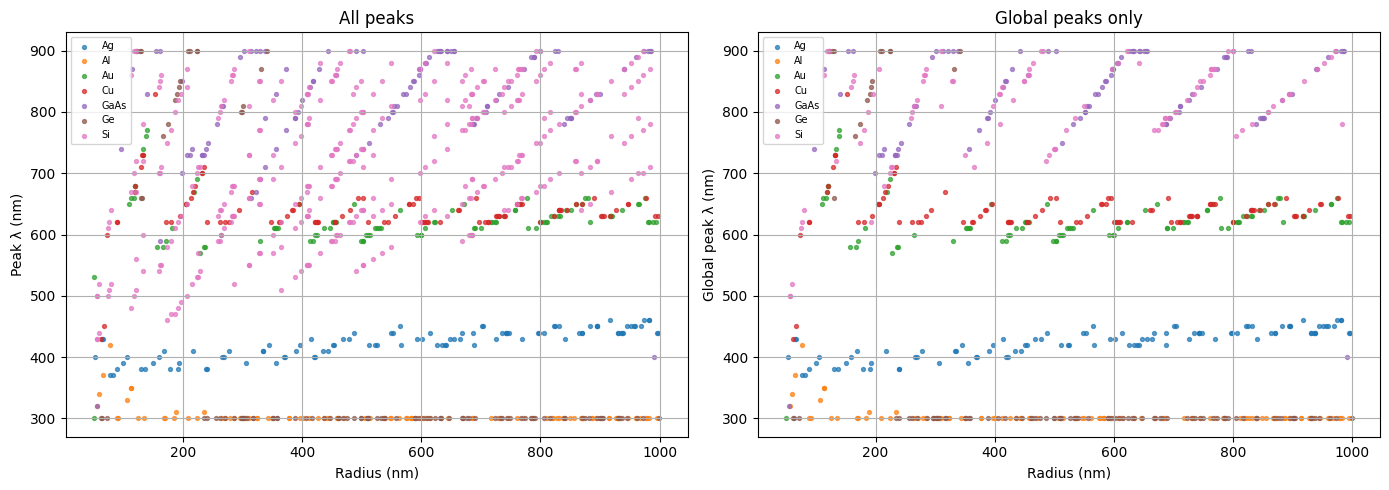

In [30]:
# Quick visual: radius vs peak wavelength, coloured by material
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mat in peak_df["material"].unique():
    sub = peak_df[peak_df["material"] == mat]
    axes[0].scatter(sub["radius_nm"], sub["lambda_peak_nm"], s=8, label=mat, alpha=0.7)
axes[0].set(xlabel="Radius (nm)", ylabel="Peak λ (nm)", title="All peaks")
axes[0].legend(fontsize=7)
axes[0].grid(True)

global_df = peak_df[peak_df["is_global"]]
for mat in global_df["material"].unique():
    sub = global_df[global_df["material"] == mat]
    axes[1].scatter(sub["radius_nm"], sub["lambda_peak_nm"], s=8, label=mat, alpha=0.7)
axes[1].set(xlabel="Radius (nm)", ylabel="Global peak λ (nm)", title="Global peaks only")
axes[1].legend(fontsize=7)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [31]:
TARGET_WL    = 650       # nm  — target resonance wavelength
TARGET_SIGMA = 771_369   # nm² — target scattering cross-section at that peak
LAMBDA_W     = 0.5      # weight for wavelength error in combined error (0-1)
SIGMA_W      = 0.5      # weight for sigma error  (LAMBDA_W + SIGMA_W = 1)
MARGIN_NM    = 30        # materials whose peak range doesn't overlap [target±margin] are discarded

material_summary = peak_df.groupby("material").agg(
    lambda_min=("lambda_peak_nm", "min"),
    lambda_max=("lambda_peak_nm", "max"),
)

candidate_materials = material_summary[
    (material_summary["lambda_min"] <= TARGET_WL + MARGIN_NM) &
    (material_summary["lambda_max"] >= TARGET_WL - MARGIN_NM)
].index.tolist()

print(f"Target λ: {TARGET_WL} nm  |  Target σ: {TARGET_SIGMA} nm²  |  Margin: ±{MARGIN_NM} nm")
print(f"Candidate materials ({len(candidate_materials)}): {candidate_materials}")

# Filter peak_df to candidates only
cand_df = peak_df[peak_df["material"].isin(candidate_materials)].copy()
print(f"Candidate (material, radius) combos: {cand_df['combo_idx'].nunique()}")

Target λ: 650 nm  |  Target σ: 771369 nm²  |  Margin: ±30 nm
Candidate materials (5): ['Au', 'Cu', 'GaAs', 'Ge', 'Si']
Candidate (material, radius) combos: 500


In [32]:
# Normalisation scales (computed once on the full candidate set)
WL_SCALE    = cand_df["lambda_peak_nm"].max() - cand_df["lambda_peak_nm"].min()
SIGMA_SCALE = cand_df["sigma_peak_nm2"].max()   # normalise by max absolute value

def combined_error(lam, sig, target_wl, target_sigma, lw=LAMBDA_W, sw=SIGMA_W):
    """Weighted normalised distance in (λ, σ) space."""
    e_lam = abs(lam  - target_wl)    / (WL_SCALE    + 1e-9)
    e_sig = abs(sig  - target_sigma) / (SIGMA_SCALE  + 1e-9)
    return lw * e_lam + sw * e_sig

def best_peak_for_group(group):
    """Return the peak row with minimum combined error for this (material, radius) group."""
    errs = group.apply(
        lambda r: combined_error(r["lambda_peak_nm"], r["sigma_peak_nm2"],
                                 TARGET_WL, TARGET_SIGMA),
        axis=1
    )
    best = group.loc[errs.idxmin()]
    return pd.Series({
        "closest_peak_nm" : best["lambda_peak_nm"],
        "closest_sigma_nm2": best["sigma_peak_nm2"],
        "combined_error"  : errs.min(),
        "wl_error_nm"     : abs(best["lambda_peak_nm"] - TARGET_WL),
        "sigma_error_nm2" : abs(best["sigma_peak_nm2"] - TARGET_SIGMA),
    })

combo_lookup = (
    cand_df.groupby(["material", "radius_nm"])
    .apply(best_peak_for_group)
    .reset_index()
)
combo_lookup = combo_lookup.sort_values("combined_error").reset_index(drop=True)

print("Best combos (brute-force baseline, dual-objective):")
print(combo_lookup[["material","radius_nm","closest_peak_nm","closest_sigma_nm2",
                    "wl_error_nm","sigma_error_nm2","combined_error"]].head(10).to_string(index=False))

Best combos (brute-force baseline, dual-objective):
material  radius_nm  closest_peak_nm  closest_sigma_nm2  wl_error_nm  sigma_error_nm2  combined_error
      Si 269.375991            650.0       6.324113e+05          0.0    138957.680215        0.008022
      Si 205.745521            650.0       5.647299e+05          0.0    206639.138178        0.011929
      Cu 293.342520            640.0       8.416138e+05         10.0     70244.836298        0.012389
      Si 310.044612            660.0       8.993412e+05         10.0    127972.160518        0.015721
      Si 329.645570            650.0       1.053139e+06          0.0    281769.855676        0.016267
      Si 310.496609            660.0       9.177904e+05         10.0    146421.395293        0.016786
      Cu 284.085671            630.0       7.980587e+05         20.0     26689.702708        0.018207
      Si 328.115324            650.0       1.087197e+06          0.0    315827.672557        0.018233
      Au 205.366245           

C:\Users\FURKAN\AppData\Local\Temp\ipykernel_26472\4046886184.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(best_peak_for_group)


In [33]:
class MieEnv:
    """
    Dual-objective RL environment: minimise combined error in (λ, σ) space.

    State  (7-dim, all normalised to [0,1]):
        [target_wl, target_sigma, mat_idx, radius_idx,
         current_peak_wl, current_peak_sigma, combined_error]

    Actions:
        0 = radius --
        1 = radius ++
        2 = prev material
        3 = next material
        4 = stop

    Reward = old_combined_error - new_combined_error  (positive = improvement)
             + STOP_BONUS / STOP_PENALTY on action=4
    """

    N_ACTIONS      = 5
    STATE_DIM      = 7
    STOP_BONUS     = 50.0
    STOP_PENALTY   = -20.0
    STOP_THRESHOLD = 0.05   # combined error (normalised) — consider 'solved'
    MAX_STEPS      = 100
    RADIUS_STEP    = 1

    def __init__(self, combo_lookup: pd.DataFrame,
                 target_wl: float, target_sigma: float,
                 wl_scale: float, sigma_scale: float,
                 lw: float = LAMBDA_W, sw: float = SIGMA_W):
        self.lookup       = combo_lookup.copy()
        self.target_wl    = target_wl
        self.target_sigma = target_sigma
        self.wl_scale     = wl_scale
        self.sigma_scale  = sigma_scale
        self.lw           = lw
        self.sw           = sw

        self.mat_list = sorted(self.lookup["material"].unique())
        self.n_mats   = len(self.mat_list)

        # Normalisation ranges (for state encoding)
        self.wl_min    = self.lookup["closest_peak_nm"].min()
        self.wl_max    = self.lookup["closest_peak_nm"].max()
        self.sig_min   = self.lookup["closest_sigma_nm2"].min()
        self.sig_max   = self.lookup["closest_sigma_nm2"].max()
        self.err_max   = self.lookup["combined_error"].max()

        self._build_index()

    # ------------------------------------------------------------------ #
    def _build_index(self):
        self.mat_radii  = {}   # mat → sorted radius list
        self.peak_table = {}   # (mat, r_idx) → (peak_wl, peak_sig, combined_err)

        for mat in self.mat_list:
            sub = self.lookup[self.lookup["material"] == mat].sort_values("radius_nm")
            self.mat_radii[mat] = sub["radius_nm"].tolist()
            for r_idx, row in enumerate(sub.itertuples()):
                self.peak_table[(mat, r_idx)] = (
                    row.closest_peak_nm,
                    row.closest_sigma_nm2,
                    row.combined_error,
                )

    # ------------------------------------------------------------------ #
    def _norm(self, val, lo, hi):
        return float(np.clip((val - lo) / (hi - lo + 1e-9), 0.0, 1.0))

    def _get_state(self):
        peak_wl, peak_sig, cerr = self.peak_table[(self.mat, self.r_idx)]
        return np.array([
            self._norm(self.target_wl,    self.wl_min,  self.wl_max),
            self._norm(self.target_sigma, self.sig_min, self.sig_max),
            self._norm(self.mat_idx,      0,            self.n_mats - 1),
            self._norm(self.r_idx,        0,            len(self.mat_radii[self.mat]) - 1),
            self._norm(peak_wl,           self.wl_min,  self.wl_max),
            self._norm(peak_sig,          self.sig_min, self.sig_max),
            self._norm(cerr,              0,            self.err_max),
        ], dtype=np.float32)

    # ------------------------------------------------------------------ #
    def reset(self):
        self.mat_idx = random.randrange(self.n_mats)
        self.mat     = self.mat_list[self.mat_idx]
        self.r_idx   = random.randrange(len(self.mat_radii[self.mat]))
        self.steps   = 0
        _, _, self.current_error = self.peak_table[(self.mat, self.r_idx)]
        return self._get_state()

    # ------------------------------------------------------------------ #
    def step(self, action: int):
        self.steps += 1
        old_error = self.current_error
        n_radii   = len(self.mat_radii[self.mat])

        if action == 0:   # radius --
            self.r_idx = max(0, self.r_idx - self.RADIUS_STEP)
        elif action == 1: # radius ++
            self.r_idx = min(n_radii - 1, self.r_idx + self.RADIUS_STEP)
        elif action == 2: # prev material
            self.mat_idx = max(0, self.mat_idx - 1)
            self.mat     = self.mat_list[self.mat_idx]
            self.r_idx   = min(self.r_idx, len(self.mat_radii[self.mat]) - 1)
        elif action == 3: # next material
            self.mat_idx = min(self.n_mats - 1, self.mat_idx + 1)
            self.mat     = self.mat_list[self.mat_idx]
            self.r_idx   = min(self.r_idx, len(self.mat_radii[self.mat]) - 1)
        elif action == 4: # stop
            bonus = self.STOP_BONUS if old_error < self.STOP_THRESHOLD else self.STOP_PENALTY
            return self._get_state(), bonus, True, self._info()

        _, _, self.current_error = self.peak_table[(self.mat, self.r_idx)]
        reward = old_error - self.current_error   # positive = improvement
        done   = self.steps >= self.MAX_STEPS
        return self._get_state(), reward, done, self._info()

    def _info(self):
        peak_wl, peak_sig, cerr = self.peak_table[(self.mat, self.r_idx)]
        return {
            "material"       : self.mat,
            "radius_nm"      : self.mat_radii[self.mat][self.r_idx],
            "closest_peak_wl": peak_wl,
            "closest_sigma"  : peak_sig,
            "wl_error_nm"    : abs(peak_wl  - self.target_wl),
            "sigma_error_nm2": abs(peak_sig - self.target_sigma),
            "combined_error" : cerr,
            "steps"          : self.steps,
        }


# Quick sanity check
env = MieEnv(combo_lookup, TARGET_WL, TARGET_SIGMA, WL_SCALE, SIGMA_SCALE)
s   = env.reset()
print("State dim :", s.shape)
print("Initial state:", s)
s2, r, done, info = env.step(1)
print("After action=1 (radius++):", info)

State dim : (7,)
Initial state: [0.5833333  0.0906776  0.25       0.08080808 0.71666664 0.021083
 0.17980084]
After action=1 (radius++): {'material': 'Cu', 'radius_nm': 132.34725695881565, 'closest_peak_wl': 730.0, 'closest_sigma': 189233.1770440007, 'wl_error_nm': 80.0, 'sigma_error_nm2': 582135.8229559993, 'combined_error': 0.10027394546172355, 'steps': 1}


In [34]:
class DQN(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden,    hidden), nn.ReLU(),
            nn.Linear(hidden,    n_actions)
        )

    def forward(self, x):
        return self.net(x)


Transition = collections.namedtuple(
    "Transition", ("state", "action", "reward", "next_state", "done")
)

class ReplayBuffer:
    def __init__(self, capacity: int = 20_000):
        self.buf = collections.deque(maxlen=capacity)

    def push(self, *args):
        self.buf.append(Transition(*args))

    def sample(self, batch_size: int):
        return random.sample(self.buf, batch_size)

    def __len__(self):
        return len(self.buf)

In [45]:
# ── Hyperparameters ─────────────────────────────────────────────────────
EPISODES      = 1200
BATCH_SIZE    = 64
GAMMA         = 0.95
LR            = 5e-4
EPS_START     = 1.0
EPS_END       = 0.05
EPS_DECAY     = 0.9985      # multiplicative per episode
TARGET_UPDATE = 50         # copy online → target net every N episodes
HIDDEN        = 128
BUFFER_CAP    = 20_000
MIN_BUFFER    = 256        # start training only after this many transitions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

env        = MieEnv(combo_lookup, TARGET_WL, TARGET_SIGMA, WL_SCALE, SIGMA_SCALE)
online_net = DQN(MieEnv.STATE_DIM, MieEnv.N_ACTIONS, HIDDEN).to(device)
target_net = DQN(MieEnv.STATE_DIM, MieEnv.N_ACTIONS, HIDDEN).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

optimizer = optim.Adam(online_net.parameters(), lr=LR)
buffer    = ReplayBuffer(BUFFER_CAP)
loss_fn   = nn.SmoothL1Loss()

epsilon         = EPS_START
episode_rewards = []
episode_errors  = []

# ── Training loop ────────────────────────────────────────────────────────
for ep in range(1, EPISODES + 1):
    state  = env.reset()
    ep_ret = 0.0

    while True:
        # ε-greedy action selection
        if random.random() < epsilon:
            action = random.randrange(MieEnv.N_ACTIONS)
        else:
            with torch.no_grad():
                t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(online_net(t).argmax(dim=1).item())

        next_state, reward, done, info = env.step(action)
        buffer.push(
            state, action, reward,
            next_state, float(done)
        )
        state   = next_state
        ep_ret += reward

        # Learning step
        if len(buffer) >= MIN_BUFFER:
            batch = buffer.sample(BATCH_SIZE)
            b     = Transition(*zip(*batch))

            s_b  = torch.tensor(np.array(b.state),      dtype=torch.float32, device=device)
            a_b  = torch.tensor(b.action,               dtype=torch.long,    device=device).unsqueeze(1)
            r_b  = torch.tensor(b.reward,               dtype=torch.float32, device=device).unsqueeze(1)
            ns_b = torch.tensor(np.array(b.next_state), dtype=torch.float32, device=device)
            d_b  = torch.tensor(b.done,                 dtype=torch.float32, device=device).unsqueeze(1)

            q_curr = online_net(s_b).gather(1, a_b)
            with torch.no_grad():
                q_next = target_net(ns_b).max(dim=1, keepdim=True).values
                q_targ = r_b + GAMMA * q_next * (1 - d_b)

            loss = loss_fn(q_curr, q_targ)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(online_net.parameters(), 1.0)
            optimizer.step()

        if done:
            break

    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    if ep % TARGET_UPDATE == 0:
        target_net.load_state_dict(online_net.state_dict())

    episode_rewards.append(ep_ret)
    episode_errors.append(info["combined_error"])

    if ep % 100 == 0:
        avg_r = np.mean(episode_rewards[-100:])
        avg_e = np.mean(episode_errors[-100:])
        print(f"Ep {ep:4d} | eps={epsilon:.3f} | avg_reward={avg_r:7.2f} | avg_combined_error={avg_e:.4f}")

print("Training done.")

Device: cuda
Ep  100 | eps=0.861 | avg_reward= -14.40 | avg_combined_error=0.2206
Ep  200 | eps=0.741 | avg_reward= -15.80 | avg_combined_error=0.2233
Ep  300 | eps=0.637 | avg_reward= -13.67 | avg_combined_error=0.2094
Ep  400 | eps=0.549 | avg_reward= -11.59 | avg_combined_error=0.2101
Ep  500 | eps=0.472 | avg_reward= -12.97 | avg_combined_error=0.1899
Ep  600 | eps=0.406 | avg_reward=  -9.46 | avg_combined_error=0.1685
Ep  700 | eps=0.350 | avg_reward= -12.26 | avg_combined_error=0.1753
Ep  800 | eps=0.301 | avg_reward=  -8.75 | avg_combined_error=0.1707
Ep  900 | eps=0.259 | avg_reward=  -8.05 | avg_combined_error=0.1610
Ep 1000 | eps=0.223 | avg_reward=  -0.33 | avg_combined_error=0.1465
Ep 1100 | eps=0.192 | avg_reward=   6.65 | avg_combined_error=0.1737
Ep 1200 | eps=0.165 | avg_reward=   2.64 | avg_combined_error=0.1842
Training done.


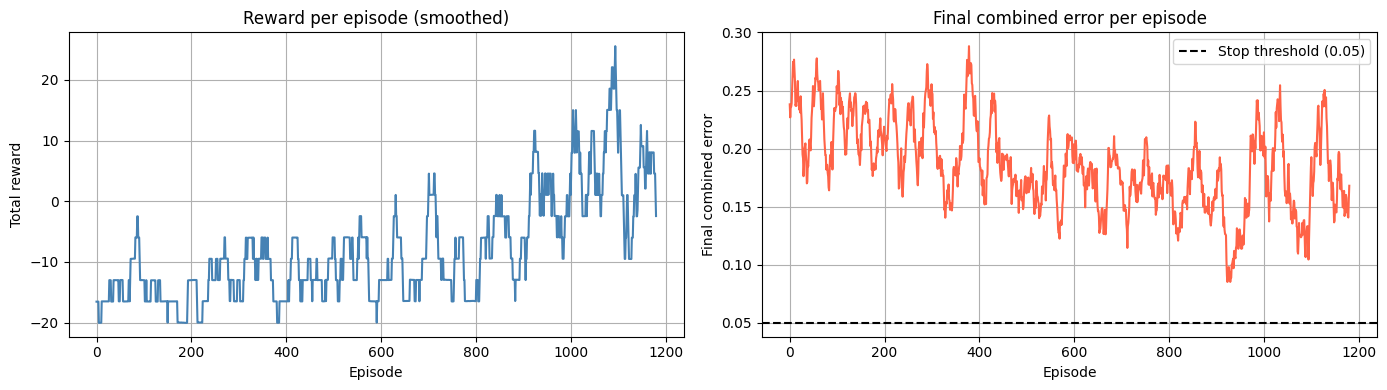

In [46]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(smooth(episode_rewards), color="steelblue")
axes[0].set(xlabel="Episode", ylabel="Total reward", title="Reward per episode (smoothed)")
axes[0].grid(True)

axes[1].plot(smooth(episode_errors), color="tomato")
axes[1].axhline(MieEnv.STOP_THRESHOLD, ls="--", color="k",
                label=f"Stop threshold ({MieEnv.STOP_THRESHOLD:.2f})")
axes[1].set(xlabel="Episode", ylabel="Final combined error", title="Final combined error per episode")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [47]:
def run_greedy(env, net, n_trials=200):
    """Run the trained agent greedily for `n_trials` episodes."""
    net.eval()
    results = []
    for _ in range(n_trials):
        state = env.reset()
        for step in range(MieEnv.MAX_STEPS):
            with torch.no_grad():
                t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(net(t).argmax(dim=1).item())
            state, _, done, info = env.step(action)
            if done:
                break
        results.append({
            "material"        : info["material"],
            "radius_nm"       : info["radius_nm"],
            "closest_peak_wl" : info["closest_peak_wl"],
            "closest_sigma"   : info["closest_sigma"],
            "wl_error_nm"     : info["wl_error_nm"],
            "sigma_error_nm2" : info["sigma_error_nm2"],
            "combined_error"  : info["combined_error"],
            "steps"           : info["steps"],
        })
    return pd.DataFrame(results)


env_eval    = MieEnv(combo_lookup, TARGET_WL, TARGET_SIGMA, WL_SCALE, SIGMA_SCALE)
dqn_results = run_greedy(env_eval, online_net, n_trials=200)

# Brute-force best
bf_best = combo_lookup.iloc[0]

print("=== Brute-Force Best (dual-objective) ===")
print(f"  Material     : {bf_best['material']}")
print(f"  Radius       : {bf_best['radius_nm']} nm")
print(f"  Peak λ       : {bf_best['closest_peak_nm']:.2f} nm  (target {TARGET_WL} nm)")
print(f"  Peak σ       : {bf_best['closest_sigma_nm2']:.0f} nm²  (target {TARGET_SIGMA} nm²)")
print(f"  λ error      : {bf_best['wl_error_nm']:.2f} nm")
print(f"  σ error      : {bf_best['sigma_error_nm2']:.0f} nm²")
print(f"  Combined err : {bf_best['combined_error']:.4f}")
print()
print("=== DQN Agent (200 greedy runs) ===")
print(f"  Mean combined error   : {dqn_results['combined_error'].mean():.4f}")
print(f"  Median combined error : {dqn_results['combined_error'].median():.4f}")
print(f"  Best combined error   : {dqn_results['combined_error'].min():.4f}")
print(f"  Mean λ error          : {dqn_results['wl_error_nm'].mean():.2f} nm")
print(f"  Mean σ error          : {dqn_results['sigma_error_nm2'].mean():.0f} nm²")
print(f"  Mean steps            : {dqn_results['steps'].mean():.1f}")
print(f"  Solved (<{MieEnv.STOP_THRESHOLD}): "
      f"{(dqn_results['combined_error'] < MieEnv.STOP_THRESHOLD).mean()*100:.1f}%")

=== Brute-Force Best (dual-objective) ===
  Material     : Si
  Radius       : 269.37599060936316 nm
  Peak λ       : 650.00 nm  (target 650 nm)
  Peak σ       : 632411 nm²  (target 771369 nm²)
  λ error      : 0.00 nm
  σ error      : 138958 nm²
  Combined err : 0.0080

=== DQN Agent (200 greedy runs) ===
  Mean combined error   : 0.1142
  Median combined error : 0.0827
  Best combined error   : 0.0080
  Mean λ error          : 35.90 nm
  Mean σ error          : 1459685 nm²
  Mean steps            : 74.1
  Solved (<0.05): 29.5%


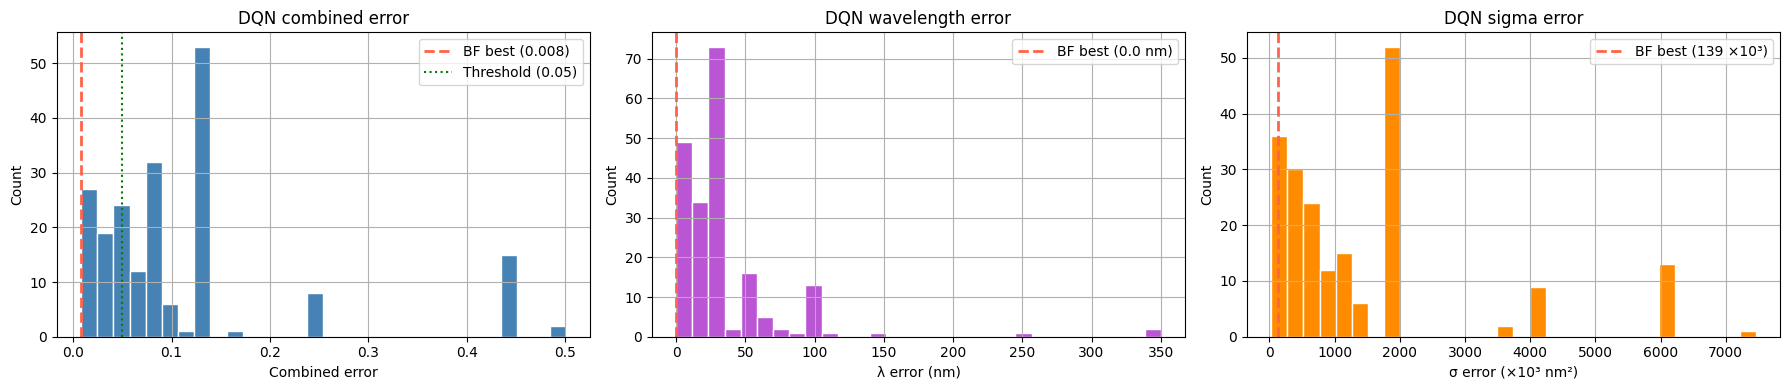

In [48]:
# Error distribution comparison — dual-objective
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Combined error histogram
axes[0].hist(dqn_results["combined_error"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(bf_best["combined_error"], color="tomato", lw=2, ls="--",
                label=f"BF best ({bf_best['combined_error']:.3f})")
axes[0].axvline(MieEnv.STOP_THRESHOLD, color="green", lw=1.5, ls=":",
                label=f"Threshold ({MieEnv.STOP_THRESHOLD})")
axes[0].set(xlabel="Combined error", ylabel="Count", title="DQN combined error")
axes[0].legend(); axes[0].grid(True)

# λ error histogram
axes[1].hist(dqn_results["wl_error_nm"], bins=30, color="mediumorchid", edgecolor="white")
axes[1].axvline(bf_best["wl_error_nm"], color="tomato", lw=2, ls="--",
                label=f"BF best ({bf_best['wl_error_nm']:.1f} nm)")
axes[1].set(xlabel="λ error (nm)", ylabel="Count", title="DQN wavelength error")
axes[1].legend(); axes[1].grid(True)

# σ error histogram
axes[2].hist(dqn_results["sigma_error_nm2"] / 1e3, bins=30, color="darkorange", edgecolor="white")
axes[2].axvline(bf_best["sigma_error_nm2"] / 1e3, color="tomato", lw=2, ls="--",
                label=f"BF best ({bf_best['sigma_error_nm2']/1e3:.0f} ×10³)")
axes[2].set(xlabel="σ error (×10³ nm²)", ylabel="Count", title="DQN sigma error")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

In [49]:
best_run = dqn_results.loc[dqn_results["combined_error"].idxmin()]
print(f"Target λ                : {TARGET_WL} nm")
print(f"Target σ                : {TARGET_SIGMA} nm²")
print(f"Best DQN material       : {best_run['material']}")
print(f"Best DQN radius         : {best_run['radius_nm']} nm")
print(f"Best DQN peak λ         : {best_run['closest_peak_wl']:.2f} nm  (err {best_run['wl_error_nm']:.2f} nm)")
print(f"Best DQN peak σ         : {best_run['closest_sigma']:.0f} nm²  (err {best_run['sigma_error_nm2']:.0f} nm²)")
print(f"Best DQN combined error : {best_run['combined_error']:.4f}")
print(f"Steps taken             : {int(best_run['steps'])}")

Target λ                : 650 nm
Target σ                : 771369 nm²
Best DQN material       : Si
Best DQN radius         : 269.37599060936316 nm
Best DQN peak λ         : 650.00 nm  (err 0.00 nm)
Best DQN peak σ         : 632411 nm²  (err 138958 nm²)
Best DQN combined error : 0.0080
Steps taken             : 1
